# Prototype rules: from a trained LogiX-GIN + prototypes to the predicates it uses

This notebook answers, on a checkpoint that already exists in `results_proto/`:

1. **Load** a trained `GINTELLProto{Node,Graph}` and check it still classifies.
2. **Show the prototype as a binary vector** — and check whether it *is* one,
   i.e. whether the prototype logits are saturated rather than sitting near 0.5.
3. **Check the prototypes are distinct** from one another.
4. **Read the head**: which prototypes each class uses, and the *exact* similarity
   threshold at which a prototype literal turns on.
5. **List the components the prototype demands** — the dimensions where `p_kj = 1`,
   ranked by how much they separate the prototype's matches from the population.
6. **Turn each demanded component into predicates** over neighbourhood atom counts,
   via `latent_logic.explain_component` (the port of `nbs/LayerWiseRules.ipynb`).
7. **Ground it**: the molecules / atoms that actually match the prototype.

Nothing here is new machinery — it is `latent_logic.py` + `explain_proto.py` driven
step by step so each intermediate object is visible.

**Short answer to "can we do this today": yes, with one measured limit.** Loading,
showing the binary prototype, reading the head's exact thresholds and expanding
components into atom-count predicates all work on the existing checkpoints. But on
these runs only **conv layer 0** produces rules short enough to read — layer-1 and
layer-2 units need ~10-literal conjunctions — while the prototypes' strongest demands
sit in layers 1-2. §6 measures this in closed form, and §5 therefore prints both the
full ranking and the decodable subset. Treat the predicates as the readable part of
the prototype, not the whole of it.

> **What a prototype rule is, exactly.** A prototype is a binary pattern
> $p_k \in \{0,1\}^d$ and the similarity is the *normalised Hamming agreement*
> $s_k = \frac1d \sum_j [\,p_{kj} l_j + (1-p_{kj})(1-l_j)\,]$.
> That is a **threshold (m-of-n) rule, not a conjunction**: the prototype does not
> require all its demands to hold, it requires *enough* of them. The head then
> applies a step literal to $s_k$, so the honest reading is
> *"at least a fraction $\theta$ of these $d$ demands hold"*, where $\theta$ is the
> threshold recovered in §4. Sections 5–6 list the demands that carry the signal;
> they characterise the prototype, they are not equivalent to it.

## 0. Setup and run selection

In [14]:
import os, sys, glob, json, pickle, textwrap
import torch
import numpy as np
import matplotlib.pyplot as plt

REPO = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'nbs' else os.getcwd()
os.chdir(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)

from torch_geometric.loader import DataLoader

from latent_logic import (ATOMS, CLASSES, collect_activations, explain_component,
                          explain_head, format_component, find_step_intervals)
from explain_proto import (derive, provenance, readout_columns, proto_dim_map,
                           atom, describe_node)
from utils.utils import get_dataset

torch.set_grad_enabled(False)

# ---- knobs ------------------------------------------------------------------
DATASET    = 'Mutagenicity'
RUN        = None                                  # None -> first run matching RUN_FILTER
RUN_FILTER = 'proto_level=node'      # 'proto_level=graph|push_every=200' for the
                                     # pushed graph-level model
SEED       = '0'
CKPT       = 'best.pt'
RULE_SPLIT = 'val'      # split the rules' support is measured on (explain_proto's default)
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROTO_K      = None     # None -> a prototype the head actually reads
TOP_DIMS     = 8        # demanded components to decode per prototype
TOP_MATCHES  = 50       # rows (graphs or nodes) used to measure lift
MAX_RULES    = 5
MIN_SUPPORT  = 2        # see latent_logic: 0 leaves ~45% of layer-0 rules vacuous
# Rule length is per conv layer: deeper units need longer conjunctions before any
# rule clears MIN_SUPPORT, and the enumeration is a subset-sum, so cost grows fast.
# Section 6 measures what each layer actually needs; raise a value if you see
# "no rule with support >= ...".
RULE_LEN      = {0: 4, 1: 6, 2: 6}
MAX_RULE_LEN  = 3       # for the head, whose inputs are the K similarities
DECODE_LAYERS = {0}     # which conv layers' demands to decode (see the diagnostic
                        # in section 6: only layer 0 has rules short enough to read)

runs = sorted(glob.glob(f'results_proto/{DATASET}/*/*/{SEED}'))
print(f'{len(runs)} runs available for seed {SEED}:\n')
for r in runs:
    a = json.load(open(f'{r}/args.json'))
    res = json.load(open(f'{os.path.dirname(r)}/results.json'))
    print(f"  level={a['proto_level']:<6s} K={a['num_prototypes']:<3d} "
          f"push_every={a['push_every']:<4d} test_acc={res['test_acc_mean']:.3f}")
    print(f"      {r}")

3 runs available for seed 0:

  level=graph  K=16  push_every=0    test_acc=0.823
      results_proto/Mutagenicity/batch_size=128|conv_reg=0.001|epochs=3000|fc_reg=0.01|l2=0.0|lr=0.001|num_prototypes=16|proto_div_reg=0.01|proto_ent_reg=0.01|proto_level=graph|push_every=0|warmup_epochs=1000/batch_size=128|dropout=0.15|epochs=500|hidden_dim=64|l2=1e-05|lr=0.001|nogumbel=False|num_layers=3/0
  level=graph  K=16  push_every=200  test_acc=0.818
      results_proto/Mutagenicity/batch_size=128|conv_reg=0.001|epochs=3000|fc_reg=0.01|l2=0.0|lr=0.001|num_prototypes=16|proto_div_reg=0.01|proto_ent_reg=0.01|proto_level=graph|push_every=200|warmup_epochs=1000/batch_size=128|dropout=0.15|epochs=500|hidden_dim=64|l2=1e-05|lr=0.001|nogumbel=False|num_layers=3/0
  level=node   K=16  push_every=0    test_acc=0.814
      results_proto/Mutagenicity/batch_size=128|conv_reg=0.001|epochs=3000|fc_reg=0.01|l2=0.0|lr=0.001|num_prototypes=16|proto_div_reg=0.01|proto_ent_reg=0.01|proto_level=node|push_every=0|war

## 1. Load the model and confirm it works

In [15]:
RUN = RUN or next(r for r in runs if RUN_FILTER in r)
args  = json.load(open(f'{RUN}/args.json'))
LEVEL = args['proto_level']

model = torch.load(f'{RUN}/{CKPT}', map_location=DEVICE, weights_only=False).eval().to(DEVICE)

dataset  = get_dataset(DATASET)
split    = pickle.load(open(f'{RUN}/data.pkl', 'rb'))
ds_rule  = dataset[split[f'{RULE_SPLIT}_indices']]
ds_test  = dataset[split['test_indices']]

def accuracy(ds):
    correct = 0
    for data in DataLoader(ds, batch_size=128, shuffle=False):
        data = data.to(DEVICE)
        pred = model(data.x.float(), data.edge_index, data.batch).argmax(-1)
        correct += pred.eq(data.y.reshape(-1)).sum().item()
    return correct / len(ds)

print(f'run    : {RUN}')
print(f'model  : {type(model).__name__}  level={LEVEL}  K={args["num_prototypes"]} '
      f'push_every={args["push_every"]}')
print(f'trunk  : {model.num_layers} conv layers x {model.hidden_dim} units '
      f'-> readout_dim {model.readout_dim} -> {model.num_classes} classes')
print(f'splits : rules/support on {RULE_SPLIT} ({len(ds_rule)} graphs), '
      f'test ({len(ds_test)} graphs)')
print(f'\ntest accuracy (this seed) : {accuracy(ds_test):.4f}')

run    : results_proto/Mutagenicity/batch_size=128|conv_reg=0.001|epochs=3000|fc_reg=0.01|l2=0.0|lr=0.001|num_prototypes=16|proto_div_reg=0.01|proto_ent_reg=0.01|proto_level=node|push_every=0|warmup_epochs=1000/batch_size=128|dropout=0.15|epochs=500|hidden_dim=64|l2=1e-05|lr=0.001|nogumbel=False|num_layers=3/0
model  : GINTELLProtoNode  level=node  K=16 push_every=0
trunk  : 3 conv layers x 64 units -> readout_dim 32 -> 2 classes
splits : rules/support on val (434 graphs), test (434 graphs)

test accuracy (this seed) : 0.8318


## 2. The prototype as a binary vector

`PrototypeLayer` stores free logits and exposes two views:

* `prototypes_soft = sigmoid(logits)` — what the model actually optimises;
* `prototypes = hard_sigmoid(logits)` — the straight-through **binary** vector,
  which is what the similarity uses in the forward pass.

So `prototypes` is *always* in $\{0,1\}^d$ by construction. The meaningful question
is whether training made it **decisive**: a logit near 0 gives a binary entry whose
sign is arbitrary and whose gradient is still live. The saturation numbers below are
that check. (`push_every > 0` snaps every prototype onto a real training row at
`|logit| = 3`, i.e. soft values `0.047 / 0.953`, so use the 0.05 band to judge a
pushed run and the 0.02 band for a free one.)

In [16]:
LI = 0                                  # prototype layer index ('both' has 2)
proto_layer = model.proto_layers[LI]

P  = proto_layer.prototypes.detach().cpu()        # {0,1}^{K x d}
Ps = proto_layer.prototypes_soft.detach().cpu()   # sigmoid(logits)
K, D = P.shape

print(f'prototype tensor : {tuple(P.shape)}  (K prototypes x d literals)')
print(f'values present   : {sorted(set(P.flatten().tolist()))}   <- binary by construction\n')

sat02 = ((Ps < 0.02) | (Ps > 0.98)).float().mean(1)
sat05 = ((Ps < 0.05) | (Ps > 0.95)).float().mean(1)
print(f'{"k":>3s} {"#ones":>6s} {"frac ones":>10s} {"sat@0.02":>9s} {"sat@0.05":>9s} '
      f'{"min|logit|":>11s}')
for k in range(K):
    print(f'{k:3d} {int(P[k].sum()):6d} {float(P[k].mean()):10.2f} '
          f'{float(sat02[k]):9.2f} {float(sat05[k]):9.2f} '
          f'{float(proto_layer.proto_logits[k].abs().min()):11.3f}')
print(f'\noverall saturation: {float(sat02.mean()):.0%} of entries within 0.02 of {{0,1}}, '
      f'{float(sat05.mean()):.0%} within 0.05')

prototype tensor : (16, 192)  (K prototypes x d literals)
values present   : [0.0, 1.0]   <- binary by construction

  k  #ones  frac ones  sat@0.02  sat@0.05  min|logit|
  0     84       0.44      0.18      0.24       0.000
  1    106       0.55      1.00      1.00      11.777
  2     87       0.45      1.00      1.00      11.192
  3    105       0.55      1.00      1.00      11.339
  4     93       0.48      1.00      1.00      11.771
  5     90       0.47      0.00      0.03       0.000
  6     95       0.49      1.00      1.00      11.746
  7     91       0.47      1.00      1.00      11.792
  8     91       0.47      0.13      0.19       0.001
  9    102       0.53      1.00      1.00      11.663
 10     74       0.39      1.00      1.00      11.495
 11    102       0.53      1.00      1.00      11.488
 12     94       0.49      1.00      1.00      11.764
 13    134       0.70      0.16      0.24       0.000
 14    109       0.57      1.00      1.00      11.831
 15    109       0.

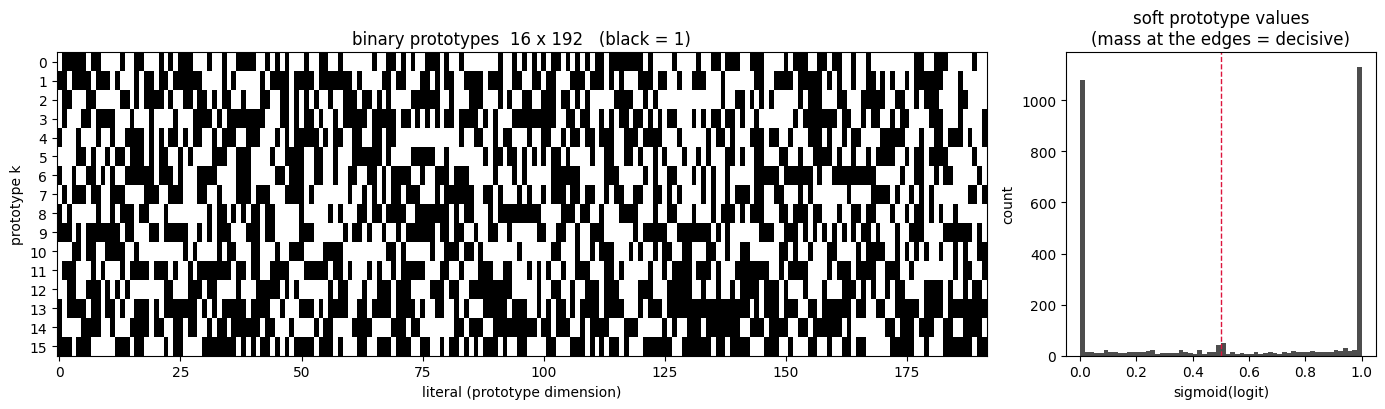

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2),
                       gridspec_kw={'width_ratios': [3, 1]})
ax[0].imshow(P.numpy(), aspect='auto', cmap='Greys', interpolation='nearest')
ax[0].set(xlabel='literal (prototype dimension)', ylabel='prototype k',
          title=f'binary prototypes  {K} x {D}   (black = 1)')
ax[0].set_yticks(range(K))
ax[1].hist(Ps.flatten().numpy(), bins=60, color='0.3')
ax[1].axvline(0.5, color='crimson', lw=1, ls='--')
ax[1].set(xlabel='sigmoid(logit)', ylabel='count',
          title='soft prototype values\n(mass at the edges = decisive)')
plt.tight_layout(); plt.show()

## 3. Are the prototypes distinct?

$K$ prototypes are only worth $K$ explanations if they are $K$ different patterns.
Pairwise agreement is the same Hamming measure used for the similarity, so 1.0 means
*identical* and ~0.5 is chance.

distinct patterns : 16 / 16
pairwise agreement: mean 0.481  max 0.651  (0.5 = chance)


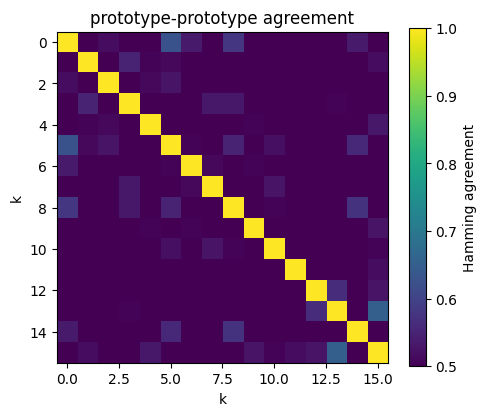

In [18]:
agree = (P @ P.t() + (1 - P) @ (1 - P).t()) / D
off   = ~torch.eye(K, dtype=torch.bool)
uniq  = {}
for k in range(K):
    uniq.setdefault(tuple(P[k].tolist()), []).append(k)

print(f'distinct patterns : {len(uniq)} / {K}')
for rows in uniq.values():
    if len(rows) > 1:
        print(f'  identical prototypes: {rows}')
print(f'pairwise agreement: mean {float(agree[off].mean()):.3f}  '
      f'max {float(agree[off].max()):.3f}  (0.5 = chance)')

plt.figure(figsize=(5, 4.2))
plt.imshow(agree.numpy(), cmap='viridis', vmin=0.5, vmax=1.0)
plt.colorbar(label='Hamming agreement')
plt.title('prototype-prototype agreement'); plt.xlabel('k'); plt.ylabel('k')
plt.tight_layout(); plt.show()

## 4. The head: which prototypes are read, and at what threshold

The head is `LogicalLayer(2·readout_dim -> C)` applied to `[s, 1-s]`. Each input goes
through `phi_in = step(w·s + b)`, which is a *periodic* square wave — so the literal
is true on a **union of intervals** of the similarity, recovered numerically by
`find_step_intervals`. A literal whose interval is all of `[0,1]` is vacuous: it is
true whatever the graph does.

This is the exact $\theta$ referred to in the header: it tells you how much agreement
with the prototype the head actually demands.

In [19]:
acts = collect_activations(model, DataLoader(ds_rule, batch_size=64, shuffle=False), DEVICE)
print(f'activations collected: {len(acts)-1} conv layers + head, '
      f'{acts[-1]["x"].shape[0]} graphs, {acts[0]["x"].shape[0]} nodes')

cols = readout_columns(model, LEVEL)          # [(kind, k, op)] x readout_dim
R    = model.readout_dim
phi  = model.fc.phi_in
tau  = phi.tau if phi.tau is not None else 10

def head_literal(j):
    '''head input j -> (kind, k, pool op, negated, interval(s) on s_k).'''
    neg = j >= R
    kind, k, op = cols[j % R]
    iv = find_step_intervals(phi.w[j].detach().cpu(), phi.b[j].detach().cpu(),
                             torch.tensor(0.), torch.tensor(1.), tau=tau)
    if neg:                       # the literal is on 1 - s_k; map it back onto s_k
        iv = sorted((1 - b, 1 - a) for a, b in iv)
    return kind, k, op, neg, iv

def fmt_iv(iv):
    return ' U '.join(f'[{a:.3f}, {b:.3f}]' for a, b in iv) or 'never true'

print(f'\n{"head input":<12s} {"literal":<18s} {"true when s_k in":<30s}')
for j in range(2 * R):
    kind, k, op, neg, iv = head_literal(j)
    vacuous = len(iv) == 1 and iv[0][0] <= 1e-6 and iv[0][1] >= 1 - 1e-6
    name = f'{"NOT " if neg else ""}p{k}.{op}'
    tag  = '   <- vacuous' if vacuous else ('   <- never fires' if not iv else '')
    print(f'{j:<12d} {name:<18s} {fmt_iv(iv):<30s}{tag}')

activations collected: 3 conv layers + head, 434 graphs, 13402 nodes

head input   literal            true when s_k in              
0            p0.mean            [0.000, 0.573]                
1            p1.mean            [0.000, 1.000]                   <- vacuous
2            p2.mean            [0.000, 1.000]                   <- vacuous
3            p3.mean            [0.000, 1.000]                   <- vacuous
4            p4.mean            [0.000, 1.000]                   <- vacuous
5            p5.mean            [0.000, 1.000]                   <- vacuous
6            p6.mean            [0.000, 1.000]                   <- vacuous
7            p7.mean            [0.000, 1.000]                   <- vacuous
8            p8.mean            [0.000, 1.000]                   <- vacuous
9            p9.mean            [0.000, 1.000]                   <- vacuous
10           p10.mean           [0.000, 1.000]                   <- vacuous
11           p11.mean           [0.000, 1.00

In [20]:
head = explain_head(model, LEVEL, acts, max_rule_len=MAX_RULE_LEN,
                    max_rules=MAX_RULES, min_support=MIN_SUPPORT)

print(f'head DNF (support measured on {RULE_SPLIT}):\n')
for cls, entries in head.items():
    print(f'  {cls}:')
    if not entries:
        print(f'    (no rule with support >= {MIN_SUPPORT} within {MAX_RULE_LEN} literals)')
    for e in entries:
        if e['always_true']:
            print('    ALWAYS TRUE  (default class)')
        else:
            print(f"    {' AND '.join(e['literals'])}"
                  f"   [support {e['support']:.1%}]")
    print()

used = sorted({int(lit.split('.')[0].replace('NOT ', '').lstrip('p'))
               for entries in head.values() for e in entries
               for lit in e['literals']})
print(f'prototypes the head reads: {used}')

head DNF (support measured on val):

  mutagen:
    p0.mean AND p8.max   [support 56.9%]
    p0.mean AND NOT p13.max   [support 52.5%]

  nonmutagen:
    (no rule with support >= 2 within 3 literals)

prototypes the head reads: [0, 8, 13]


### Which prototypes does the head actually use — and are those the decisive ones?

§2 measured how saturated each prototype is; the cell above says which ones the head
reads. Cross them. On every run in `results_proto/` (3 configurations x 3 seeds
checked) the answer is the same and it is not the comfortable one: **the head puts
essentially no weight on the saturated prototypes**. The crisp binary patterns are the
ones the classifier ignores; the ones that drive the prediction sit near logit 0,
where `hard_sigmoid` is deciding their entries on a hair.

A plausible mechanism — stated as a hypothesis, not measured here — is that it runs
the other way round: a prototype the head has pruned gets no gradient from the task
loss, so only `proto_ent_reg` acts on it and drives it to saturation, while a
prototype that carries signal has the task loss pulling against that term. Either
direction, the consequence for reading a prototype is the same.

In [21]:
kind_LI = 'node' if ((LEVEL == 'node') or (LEVEL == 'both' and LI == 0)) else 'graph'
W = model.fc.weight.detach().cpu()               # [C x 2*readout_dim], non-negative

mass = torch.zeros(K)
for j in range(2 * R):
    kind, k, op = cols[j % R]
    if kind == kind_LI:
        mass[k] += float(W[:, j].abs().sum())

in_head = {k for entries in head.values() for e in entries for lit in e['literals']
           for k in [int(lit.split('.')[0].replace('NOT ', '').lstrip('p'))]}

print(f'{"k":>3s} {"sat@0.02":>9s} {"head weight mass":>17s} {"in head DNF":>12s}')
for k in range(K):
    print(f'{k:3d} {float(sat02[k]):9.2f} {float(mass[k]):17.4f} '
          f'{"yes" if k in in_head else "":>12s}')

hi = sat02 > 0.9
if hi.any() and (~hi).any():
    print(f'\nsaturated prototypes ({int(hi.sum())}/{K}): '
          f'mean head mass {float(mass[hi].mean()):.4f}')
    print(f'unsaturated      ({int((~hi).sum())}/{K}): '
          f'mean head mass {float(mass[~hi].mean()):.4f}')
    print(f'\n-> the prototypes the classifier uses are the ones whose binary pattern '
          f'training did NOT pin down.')
else:
    print(f'\n(all prototypes fall on one side of the saturation split; '
          f'nothing to compare on this run)')

  k  sat@0.02  head weight mass  in head DNF
  0      0.18            0.3201          yes
  1      1.00            0.0000             
  2      1.00            0.0000             
  3      1.00            0.0000             
  4      1.00            0.0000             
  5      0.00            5.1471             
  6      1.00            0.0000             
  7      1.00            0.0000             
  8      0.13            0.1303          yes
  9      1.00            0.0000             
 10      1.00            0.0000             
 11      1.00            0.0000             
 12      1.00            0.0000             
 13      0.16            0.7522          yes
 14      1.00            0.0000             
 15      0.07            6.4559             

saturated prototypes (11/16): mean head mass 0.0000
unsaturated      (5/16): mean head mass 2.5611

-> the prototypes the classifier uses are the ones whose binary pattern training did NOT pin down.


## 5. The components the chosen prototype demands

About half of a prototype's entries are 1 and most carry no information, so listing
all of them is useless. A demanded dimension is **characteristic** when the rows that
match the prototype hold it far more often than the population does — that is the
*lift*. (Ranking by rarity instead selects dimensions that never fire, which describe
nothing; this is the same argument as in `explain_proto.components`, applied here to
the graph level too, where that function only takes the first active dims.)

For the **graph** model a dimension is `pool_op(L{l}u{u})`: a pooled concept.
For the **node** model it is a concept `L{l}u{u}` of one node directly.

Two tables follow. The first ranks **all** demands — that is what the prototype
actually keys on, and on these runs the winners sit in conv layers 1-2. The second
restricts to `DECODE_LAYERS`, because only those layers have conjunctions short
enough to read; §6 measures exactly why.

In [22]:
def informative(k):
    '''does either head literal on p_k carve out anything?'''
    for j in (k, k + R):
        if j >= 2 * R: continue
        iv = head_literal(j)[4]
        if iv and not (len(iv) == 1 and iv[0][0] <= 1e-6 and iv[0][1] >= 1 - 1e-6):
            return True
    return False

if PROTO_K is None:
    PROTO_K = next((k for k in used if informative(k)), used[0] if used else 0)
print(f'explaining prototype p{PROTO_K} '
      f'(head reads {used}; informative literal: {informative(PROTO_K)})\n')

xs, batch, H, feats = derive(model, acts)
Fm   = feats[LI].cpu()                                   # rows the prototypes see
sim  = proto_layer.similarity(Fm.to(DEVICE)).cpu()       # [n x K]
dmap = proto_dim_map(model, LEVEL, LI)                   # dim -> (pool op | None, layer, unit)
rate = (Fm > 0.5).float().mean(0)                        # population rate per dim

row = 'graphs' if (LEVEL == 'graph' or (LEVEL == 'both' and LI == 1)) else 'nodes'
top = sim[:, PROTO_K].argsort(descending=True)[:TOP_MATCHES]
print(f'prototype p{PROTO_K}  ({row}-level, d={D})')
print(f'  similarity over {Fm.shape[0]} {row}: min {float(sim[:, PROTO_K].min()):.3f} '
      f'median {float(sim[:, PROTO_K].median()):.3f} max {float(sim[:, PROTO_K].max()):.3f}')
print(f'  the binary vector (first 96 of {D} entries):')
bits = ''.join(str(int(v)) for v in P[PROTO_K].tolist())
for i in range(0, min(96, D), 48):
    print(f'    [{i:>3d}] {bits[i:i+48]}')

sat      = ((Ps[PROTO_K] < 0.05) | (Ps[PROTO_K] > 0.95))
top_rate = (Fm[top] > 0.5).float().mean(0)              # rate among the best matches
dim_layer = torch.tensor([dmap[d][1] for d in range(D)])

def rank(demanded_true, layers=None):
    mask = (P[PROTO_K] > 0.5) if demanded_true else (P[PROTO_K] <= 0.5)
    if layers is not None:
        mask = mask & torch.tensor([int(l) in layers for l in dim_layer.tolist()])
    dims = mask.nonzero(as_tuple=True)[0]
    # lift = how much more (or less) the best matches hold the dim than the population
    lift = (top_rate[dims] - rate[dims]) if demanded_true else (rate[dims] - top_rate[dims])
    order = lift.argsort(descending=True)[:TOP_DIMS]
    return dims[order], lift[order]

def dim_table(dims, lifts, want, title):
    print(f'\n  {title} -- demands {want} (top {len(dims)} by lift over the '
          f'{TOP_MATCHES} best-matching {row})')
    print(f'    {"dim":>5s} {"component":<20s} {"pop rate":>9s} {"in top":>8s} '
          f'{"lift":>7s} {"sat":>5s}')
    for d, l in zip(dims.tolist(), lifts.tolist()):
        op, lay, u = dmap[d]
        tag = f'L{lay}u{u}' + (f' [{op}]' if op else '')
        print(f'    {d:5d} {tag:<20s} {float(rate[d]):9.2f} '
              f'{float(top_rate[d]):8.2f} {l:+7.2f} '
              f'{"yes" if bool(sat[d]) else "NO":>5s}')

# (a) what the prototype keys on, over every layer -- the honest ranking
all_on,  lift_all_on  = rank(True)
all_off, lift_all_off = rank(False)
dim_table(all_on,  lift_all_on,  'TRUE',  'ALL LAYERS')
dim_table(all_off, lift_all_off, 'FALSE', 'ALL LAYERS')

# (b) the same, restricted to the layers whose rules are short enough to read
sel_on,  lift_on  = rank(True,  DECODE_LAYERS)
sel_off, lift_off = rank(False, DECODE_LAYERS)
dim_table(sel_on,  lift_on,  'TRUE',  f'LAYERS {sorted(DECODE_LAYERS)} (decoded below)')
dim_table(sel_off, lift_off, 'FALSE', f'LAYERS {sorted(DECODE_LAYERS)} (decoded below)')

print('\n  "sat" = the prototype logit is saturated; NO means this demand\'s sign was '
      'not decided by training.')
print(f'  layers among the top demands overall: '
      f'{sorted(set(dim_layer[torch.cat([all_on, all_off])].tolist()))}')

explaining prototype p0 (head reads [0, 8, 13]; informative literal: True)

prototype p0  (nodes-level, d=192)
  similarity over 13402 nodes: min 0.360 median 0.581 max 0.684
  the binary vector (first 96 of 192 entries):
    [  0] 011111011000010011000101011100010010011110010101
    [ 48] 000100110010000001001101010011101001000000010010

  ALL LAYERS -- demands TRUE (top 8 by lift over the 50 best-matching nodes)
      dim component             pop rate   in top    lift   sat
       83 L1u19                     0.08     1.00   +0.92   yes
      143 L2u15                     0.03     0.94   +0.91   yes
      153 L2u25                     0.04     0.94   +0.90    NO
       73 L1u9                      0.10     1.00   +0.90   yes
      167 L2u39                     0.04     0.94   +0.90   yes
      144 L2u16                     0.04     0.94   +0.90    NO
      103 L1u39                     0.06     0.96   +0.90    NO
      182 L2u54                     0.05     0.94   +0.89   yes

  ALL

## 6. From components to predicates

Each demanded component is a unit of a `GINConv(LogicalLayer)` built with `eps=0`, so
the LogicalLayer sees the **closed-neighbourhood sum** of its inputs — a *count*. Its
second stage has non-negative weights, hence is monotone in the literals, hence
"which literal sets make the unit fire" is a subset-sum problem. That is exactly what
`latent_logic.explain_component` enumerates, pruned to conjunctions that at least
`MIN_SUPPORT` observed examples satisfy.

`#X in [a, b]` reads *"the number of X in the closed neighbourhood lies in [a, b]"*;
`#NOT X` counts neighbours that are **not** X.

### First: which layers actually decode?

Rule extraction is not guaranteed to return anything, and on these runs it mostly
does not past layer 0. The reason is measurable in closed form and costs nothing.

`find_logic_rules` needs a subset of literals whose weights sum to `-b`. Taking the
largest weights first gives the **minimum length** of any sufficient conjunction — an
exact lower bound. If that bound exceeds `max_rule_len`, no search at any support
setting will ever return a rule.

Run this before reading any formula: an empty §6 is then a measured property of the
weights, not a bug. (Verified against the search itself: sampled layer-1 units return
nothing at `max_rule_len` 3, 4, 5, 6 *or* 8, and nothing at `min_support` 0 either —
consistent with the bound below, and not a support problem.)

In [23]:
def min_rule_len(layer_module):
    '''Shortest conjunction that can possibly fire each unit.

    `find_logic_rules` keeps literals with `w > 1e-5` and needs their weights to sum
    to `t_out = -b`. Taking the largest weights first therefore gives the *minimum
    cardinality* of any sufficient subset -- an exact lower bound on rule length, at
    no search cost. A unit whose bound exceeds `max_rule_len` can never return a rule.
    '''
    w, t_out = layer_module.weight.detach(), -layer_module.b.detach()
    out = []
    for u in range(layer_module.out_features):
        if float(t_out[u]) <= 0:
            out.append(0)                      # fires with no literal at all
            continue
        ws = w[u][w[u] > 1e-5].sort(descending=True).values
        hit = (ws.cumsum(0) >= t_out[u]).nonzero()
        out.append(int(hit[0]) + 1 if len(hit) else 10 ** 6)
    return torch.tensor(out, dtype=torch.float)

print(f'  {"layer":>6s} {"units":>6s} {"fire rate":>10s} {"RULE_LEN":>9s} '
      f'{"min len: median":>16s} {"<=RULE_LEN":>11s} {"unreachable":>12s}')
for lay, conv in enumerate(model.convs):
    m_ = min_rule_len(conv.nn[0])
    fin = m_[m_ < 1e6]
    print(f'  {lay:6d} {conv.nn[0].out_features:6d} '
          f'{float(acts[lay]["y_bin"].float().mean()):10.2f} {RULE_LEN[lay]:9d} '
          f'{int(fin.median()) if len(fin) else 0:16d} '
          f'{int((m_ <= RULE_LEN[lay]).sum()):11d} {int((m_ >= 1e6).sum()):12d}')
m_ = min_rule_len(model.fc)
print(f'  {"head":>6s} {model.fc.out_features:6d} '
      f'{float(acts[-1]["y_bin"].float().mean()):10.2f} {MAX_RULE_LEN:9d} '
      f'{int(m_[m_ < 1e6].median()):16d} {int((m_ <= MAX_RULE_LEN).sum()):11d} '
      f'{int((m_ >= 1e6).sum()):12d}')

print(f'\nDECODE_LAYERS = {sorted(DECODE_LAYERS)}: the layers whose units can be '
      f'written as a conjunction of at most RULE_LEN literals.')

   layer  units  fire rate  RULE_LEN  min len: median  <=RULE_LEN  unreachable
       0     64       0.39         4                3          63            1
       1     64       0.26         6               10           5            0
       2     64       0.06         6               10           1            0
    head      2       0.50         3                1           2            0

DECODE_LAYERS = [0]: the layers whose units can be written as a conjunction of at most RULE_LEN literals.


In [28]:
cache = {}
def decode(d):
    op, lay, u = dmap[d]
    if (lay, u) not in cache:
        e = explain_component(model, lay, u, acts, max_rule_len=RULE_LEN[lay],
                              max_rules=MAX_RULES, min_support=MIN_SUPPORT,
                              recursive=False)
        # most-supported first: a 42%-support rule says far more than a 0.05% one,
        # and the enumeration returns them in weight order, not support order.
        cache[(lay, u)] = sorted(e['components'][(lay, u)]['rules'],
                                 key=lambda r: -r['support'])
    return op, lay, u, cache[(lay, u)]

def show(dims, want):
    print(f'\n{"="*78}\n  p{PROTO_K} demands these components {want}\n{"="*78}')
    for d in dims.tolist():
        op, lay, u, rules = decode(d)
        tag = f'L{lay}u{u}' + (f'  pooled by {op}' if op else '')
        print(f'\n  dim {d}: {tag}   (population rate {float(rate[d]):.2f})')
        if not rules:
            print(f'      NO rule with support >= {MIN_SUPPORT} within '
                  f'{RULE_LEN[lay]} literals -- raise RULE_LEN[{lay}]')
        for r in rules:                       # support-ordered, best first
            if r['always_true']:
                print('      ALWAYS TRUE on the observed data')
                continue
            prec = '-' if r['precision'] is None else f"{r['precision']:.0%}"
            print(f"      {' AND '.join(nm for _, _, nm in r['literals'])}")
            #print(f"          support {r['support']:.2%} | precision {prec}")

show(sel_on,  'TRUE')
show(sel_off, 'FALSE')


  p0 demands these components TRUE

  dim 2: L0u2   (population rate 0.41)
      #O in [0.68, 2.12] U [3.55, 4.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Br in [1.00, 4.50]
      #N in [0.84, 2.55] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Br in [1.00, 4.50]
      #F in [0.67, 3.00] AND #NOT Br in [1.00, 4.50]
      #F in [0.67, 3.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Ca in [3.16, 5.00]
      #F in [0.67, 3.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT F in [2.41, 4.36]

  dim 47: L0u47   (population rate 0.58)
      #C in [0.62, 2.77] U [4.92, 5.00] AND #O in [0.68, 2.12] U [3.55, 4.00] AND #NOT C in [0.34, 2.78] AND #NOT S in [1.00, 2.81]
      #C in [0.62, 2.77] U [4.92, 5.00] AND #O in [0.68, 2.12] U [3.55, 4.00] AND #NOT H in [0.75, 2.13] U [3.50, 4.88] AND #NOT S in [1.00, 2.81]
      #C in [0.62, 2.77] U [4.92, 5.00] AND #Cl in [0.77, 2.46] AND #NOT H in [0.75, 2.13] U [3.50, 4.88] AND #NOT S in [1.00, 2.81]
      #C in [0.62, 2.77

### The rule card

In [25]:
def literal_line(d, negate):
    op, lay, u, rules = decode(d)
    unit = f'L{lay}u{u}'
    tag  = f'{op}({unit})' if op else unit
    if not rules:
        return f'    {"NOT " if negate else "    "}{tag:<20s} = <no supported rule>'
    r = rules[0]                                   # best-supported disjunct
    if r['always_true']:
        rhs, sup = 'ALWAYS TRUE', ''
    else:
        rhs = ' AND '.join(nm for _, _, nm in r['literals'])
        sup = f"   [support {r['support']:.1%}, {len(rules)} disjuncts total]"
    head_ = f'    {"NOT " if negate else "    "}{tag:<20s} ='
    return head_ + '\n' + textwrap.indent(textwrap.fill(rhs + sup, 96), ' ' * 10)

thr = [head_literal(j) for j in range(2 * R)]
mine = [(neg, iv) for kind, k, op, neg, iv in thr if k == PROTO_K]
print(f'PROTOTYPE p{PROTO_K}  of  {os.path.basename(os.path.dirname(os.path.dirname(RUN)))}')
print(f'level={LEVEL}  d={D}  ones={int(P[PROTO_K].sum())}\n')
print(f'  s_{PROTO_K}(G) = fraction of the {D} demands below that G meets')
for neg, iv in mine:
    print(f'  head literal {"NOT " if neg else ""}p{PROTO_K}: true when '
          f's_{PROTO_K} in {fmt_iv(iv)}')
print(f'\n  the {TOP_DIMS} most characteristic demands, each expanded into predicates:\n')
for d in sel_on.tolist():
    print(literal_line(d, False))
for d in sel_off.tolist():
    print(literal_line(d, True))
print(f'\n  classes that read p{PROTO_K}:')
for cls, entries in head.items():
    for e in entries:
        if any(f'p{PROTO_K}.' in lit for lit in e['literals']):
            print(f"    {cls}  <-  {' AND '.join(e['literals'])}  "
                  f"[support {e['support']:.1%}]")

PROTOTYPE p0  of  batch_size=128|conv_reg=0.001|epochs=3000|fc_reg=0.01|l2=0.0|lr=0.001|num_prototypes=16|proto_div_reg=0.01|proto_ent_reg=0.01|proto_level=node|push_every=0|warmup_epochs=1000
level=node  d=192  ones=84

  s_0(G) = fraction of the 192 demands below that G meets
  head literal p0: true when s_0 in [0.000, 0.573]
  head literal p0: true when s_0 in [0.000, 1.000]
  head literal NOT p0: true when s_0 in [0.000, 1.000]
  head literal NOT p0: true when s_0 in [0.000, 1.000]

  the 8 most characteristic demands, each expanded into predicates:

        L0u2                 =
          #O in [0.68, 2.12] U [3.55, 4.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Br in
          [1.00, 4.50]   [support 4.6%, 5 disjuncts total]
        L0u47                =
          #C in [0.62, 2.77] U [4.92, 5.00] AND #O in [0.68, 2.12] U [3.55, 4.00] AND #NOT C in [0.34,
          2.78] AND #NOT S in [1.00, 2.81]   [support 2.3%, 5 disjuncts total]
        L0u8                 =
    

### Expanding one component all the way down

`explain_component(..., recursive=True)` keeps expanding: a layer-2 unit is written
over layer-1 units, those over layer-0 units, and layer 0 bottoms out at atom counts.

In [26]:
d0 = int(sel_on[0])
op0, lay0, u0 = dmap[d0]
full = explain_component(model, lay0, u0, acts, max_rule_len=RULE_LEN[lay0],
                         max_rules=MAX_RULES, min_support=MIN_SUPPORT, recursive=True)
print(f'full expansion of dim {d0} = L{lay0}u{u0}'
      f'{f" (pooled by {op0})" if op0 else ""}\n')
print(format_component(full, model))

full expansion of dim 2 = L0u2

L0u2   <- requested
    #F in [0.67, 3.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Ca in [3.16, 5.00]
      support 0.112% · precision 53%
    #O in [0.68, 2.12] U [3.55, 4.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Br in [1.00, 4.50]
      support 4.611% · precision 100%
    #F in [0.67, 3.00] AND #NOT Br in [1.00, 4.50]
      support 0.276% · precision 100%
    #F in [0.67, 3.00] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT F in [2.41, 4.36]
      support 0.060% · precision 100%
    #N in [0.84, 2.55] AND #NOT N in [0.00, 1.76] U [3.57, 5.00] AND #NOT Br in [1.00, 4.50]
      support 4.358% · precision 100%



## 7. Grounding: what actually matches the prototype

A free prototype (`push_every 0`) is not a training example, so the honest way to say
what it stands for is the population it fires on. With `push_every > 0` the last push
snapped it onto a real row, listed in `push_log.json`.

In [27]:
node_graph, node_local, graph_y, A, NB = provenance(ds_rule)

if row == 'graphs':
    idx = top[:10].tolist()
    print(f'top-10 {RULE_SPLIT} molecules by agreement with p{PROTO_K}:\n')
    print(f'  {"graph":>6s} {"sim":>6s} {"class":<12s} {"n_atoms":>8s}  formula-ish')
    for g in idx:
        data = ds_rule[g]
        counts = data.x.float().sum(0)
        comp = ' '.join(f'{ATOMS[i]}{int(counts[i])}'
                        for i in counts.argsort(descending=True).tolist()
                        if counts[i] > 0 and i < len(ATOMS))
        print(f'  {g:6d} {float(sim[g, PROTO_K]):6.3f} '
              f'{CLASSES[int(data.y)]:<12s} {data.num_nodes:8d}  {comp}')
    y_top = graph_y[torch.tensor(top.tolist())]
    print(f'\nclass balance of the top {TOP_MATCHES}: '
          + '  '.join(f'{CLASSES[c]} {float((y_top == c).float().mean()):.0%}'
                      for c in range(len(CLASSES))))
    print('population                : '
          + '  '.join(f'{CLASSES[c]} {float((graph_y == c).float().mean()):.0%}'
                      for c in range(len(CLASSES))))
else:
    from collections import Counter
    envs, atoms_seen = Counter(), Counter()
    print(f'top-10 {RULE_SPLIT} atoms by agreement with p{PROTO_K}:\n')
    for r_i, n in enumerate(top.tolist()):
        g, ln = int(node_graph[n]), int(node_local[n])
        sym, env = describe_node(ds_rule[g], ln)
        envs[(sym, tuple(env))] += 1
        atoms_seen[sym] += 1
        if r_i < 10:
            print(f'  node {n:6d}  sim {float(sim[n, PROTO_K]):.3f}  '
                  f'graph {g:5d} ({CLASSES[int(graph_y[g])]:<11s})  '
                  f'{sym} bonded to {env}')
    print(f'\natom types among the top {TOP_MATCHES}: '
          + '  '.join(f'{s} {c/len(top):.0%}' for s, c in atoms_seen.most_common(4)))
    print('most common 1-hop environments:')
    for (sym, env), c in envs.most_common(5):
        print(f'  {c:4d}x  {sym} bonded to {list(env)}')
    # `top` indexes NODES; graph_y has one entry per graph, so route through node_graph
    y_top = graph_y[node_graph[top]]
    print(f'\nclass of the molecules these atoms come from: '
          + '  '.join(f'{CLASSES[c]} {float((y_top == c).float().mean()):.0%}'
                      for c in range(len(CLASSES))))

push_log = f'{RUN}/push_log.json'
pl = json.load(open(push_log)) if os.path.exists(push_log) else []
if pl:                       # written only when push_every > 0; otherwise an empty list
    print(f'\nlast push (epoch {pl[-1]["epoch"]}): p{PROTO_K} was snapped onto '
          f'training row {pl[-1]["indices"][LI][PROTO_K]}')
    print('(row index is into the TRAIN split in loader order, not ds_rule)')
else:
    print(f'\nno pushes in this run (push_every={args["push_every"]}), so p{PROTO_K} '
          f'is a free binary vector, not a training example. The population above is '
          f'the only thing it stands for.')

top-10 val atoms by agreement with p0:

  node   7779  sim 0.684  graph   250 (nonmutagen )  O bonded to ['S']
  node   7780  sim 0.684  graph   250 (nonmutagen )  O bonded to ['S']
  node   8058  sim 0.680  graph   260 (nonmutagen )  F bonded to ['C']
  node   3914  sim 0.680  graph   125 (nonmutagen )  F bonded to ['C']
  node   8059  sim 0.680  graph   260 (nonmutagen )  F bonded to ['C']
  node   8060  sim 0.680  graph   260 (nonmutagen )  F bonded to ['C']
  node   3915  sim 0.680  graph   125 (nonmutagen )  F bonded to ['C']
  node   3916  sim 0.680  graph   125 (nonmutagen )  F bonded to ['C']
  node  12939  sim 0.680  graph   415 (nonmutagen )  F bonded to ['C']
  node   3748  sim 0.680  graph   119 (mutagen    )  F bonded to ['C']

atom types among the top 50: O 54%  F 36%  H 6%  C 4%
most common 1-hop environments:
    23x  O bonded to ['H', 'S']
    18x  F bonded to ['C']
     4x  O bonded to ['S']
     3x  H bonded to ['O']
     2x  C bonded to ['C', 'F', 'F', 'F']

class o

## What this does and does not establish

**Does.** Every step above is exact arithmetic on the trained weights, not a post-hoc
surrogate: the binary prototype is the tensor the forward pass uses; the head
thresholds come from scanning the actual `step` literal; the component formulas come
from the subset-sum enumeration over non-negative weights, with measured support and
precision on a held-out split.

**Does not.**

1. **A prototype is an m-of-n rule, not a conjunction.** §5–6 list the demands that
   best separate its matches; meeting all of them is neither necessary nor sufficient
   for the head literal to fire. The only exact statement is the threshold in §4.
2. **Unsaturated entries are noise, and they are the ones that matter.** Check the
   `sat` column in §5 — a demand whose logit sits near 0 flipped on a coin toss. §4
   makes this worse than a footnote: the head puts weight almost exclusively on the
   *unsaturated* prototypes, so the patterns being read off are the least determined
   ones. Treat a specific bit of a used prototype as unreliable unless its logit is
   large; the population it fires on (§7) is the sturdier description.
3. **Duplicate prototypes** (§3) mean fewer distinct explanations than `K` suggests.
4. **Support is what makes a rule mean anything.** A subset that clears the threshold
   is formally valid even if no molecule satisfies it; `MIN_SUPPORT` prunes those, and
   the printed support/precision is how far to trust each line.
5. **Graph-level demands are pooled.** `mean(L1u17)` is a statement about the average
   over the molecule's atoms, so its atom-count expansion describes the *concept*, not
   a specific atom.
6. **Only layer 0 decodes on these runs, and the prototypes key on layers 1-2.**
   This is the sharpest limitation, and §6 measures it exactly: layer-0 units fire on
   conjunctions of ~3 literals, layer-1 and layer-2 units need ~10, so no readable
   rule exists for them at any support setting. Meanwhile the highest-lift demands of
   the graph-level prototypes sit in layers 1-2. So the predicates printed here are
   the decodable *part* of what the prototype uses, not all of it. Closing that gap is
   a training problem — sparser `conv_reg` on the deeper `LogicalLayer`s, so their
   weight mass concentrates the way layer 0's does — not something a reader can fix.